/Users/sinanhe/Documents/demogorgn/env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


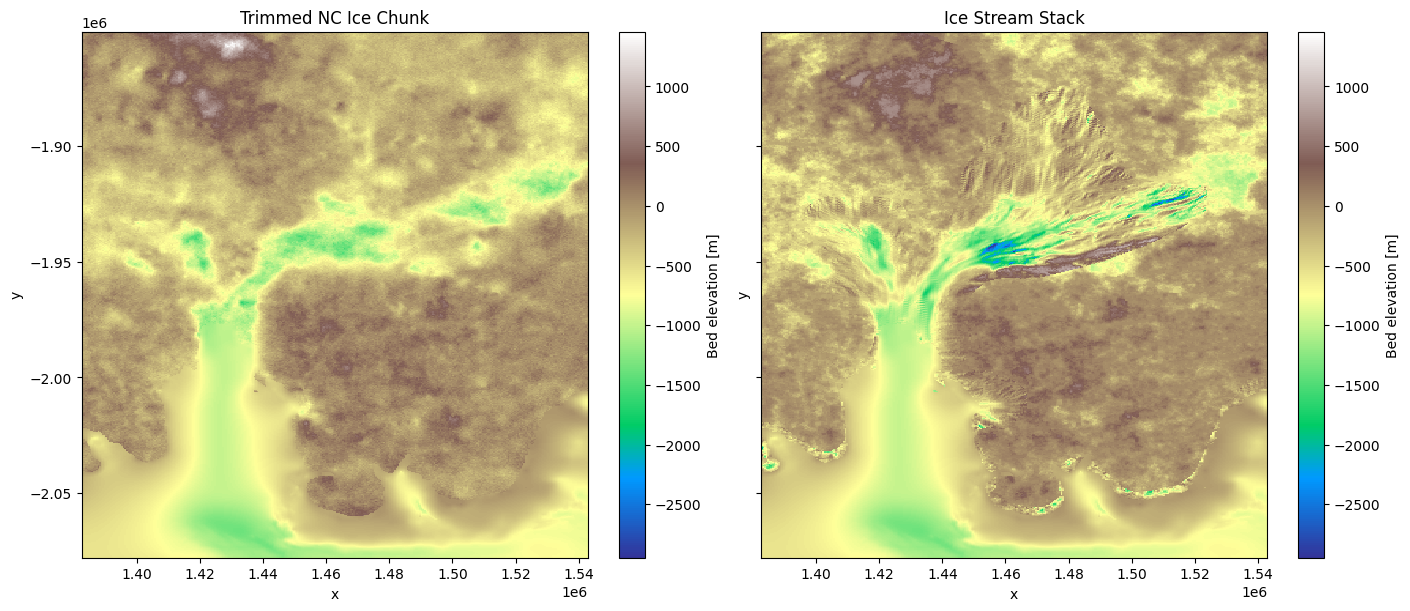

In [1]:
from demogorgn_update import DEMOGORGN_update
import matplotlib.pyplot as plt
import numpy as np

updata = DEMOGORGN_update()
ice_stream_stack = updata.build_ice_stream_stack()
ice_chunk_stack = updata.build_ice_chunk_stack()

# plot the first realization with the same colormap and shared color limits
plot_chunk = updata.ice_chunk_stack[0]
plot_stream = updata.ice_stream_stack[0]
shared_vmin = np.nanmin([plot_chunk.min(), plot_stream.min()])
shared_vmax = np.nanmax([plot_chunk.max(), plot_stream.max()])

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True, sharex=True, sharey=True)

im0 = axes[0].pcolormesh(updata.coord[0], updata.coord[1], plot_chunk, cmap='terrain', vmin=shared_vmin, vmax=shared_vmax)
axes[0].set_title('Trimmed NC Ice Chunk')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
fig.colorbar(im0, ax=axes[0], label='Bed elevation [m]')

im1 = axes[1].pcolormesh(updata.coord[0], updata.coord[1], plot_stream, cmap='terrain', vmin=shared_vmin, vmax=shared_vmax)
axes[1].set_title('Ice Stream Stack')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
fig.colorbar(im1, ax=axes[1], label='Bed elevation [m]')

plt.show()


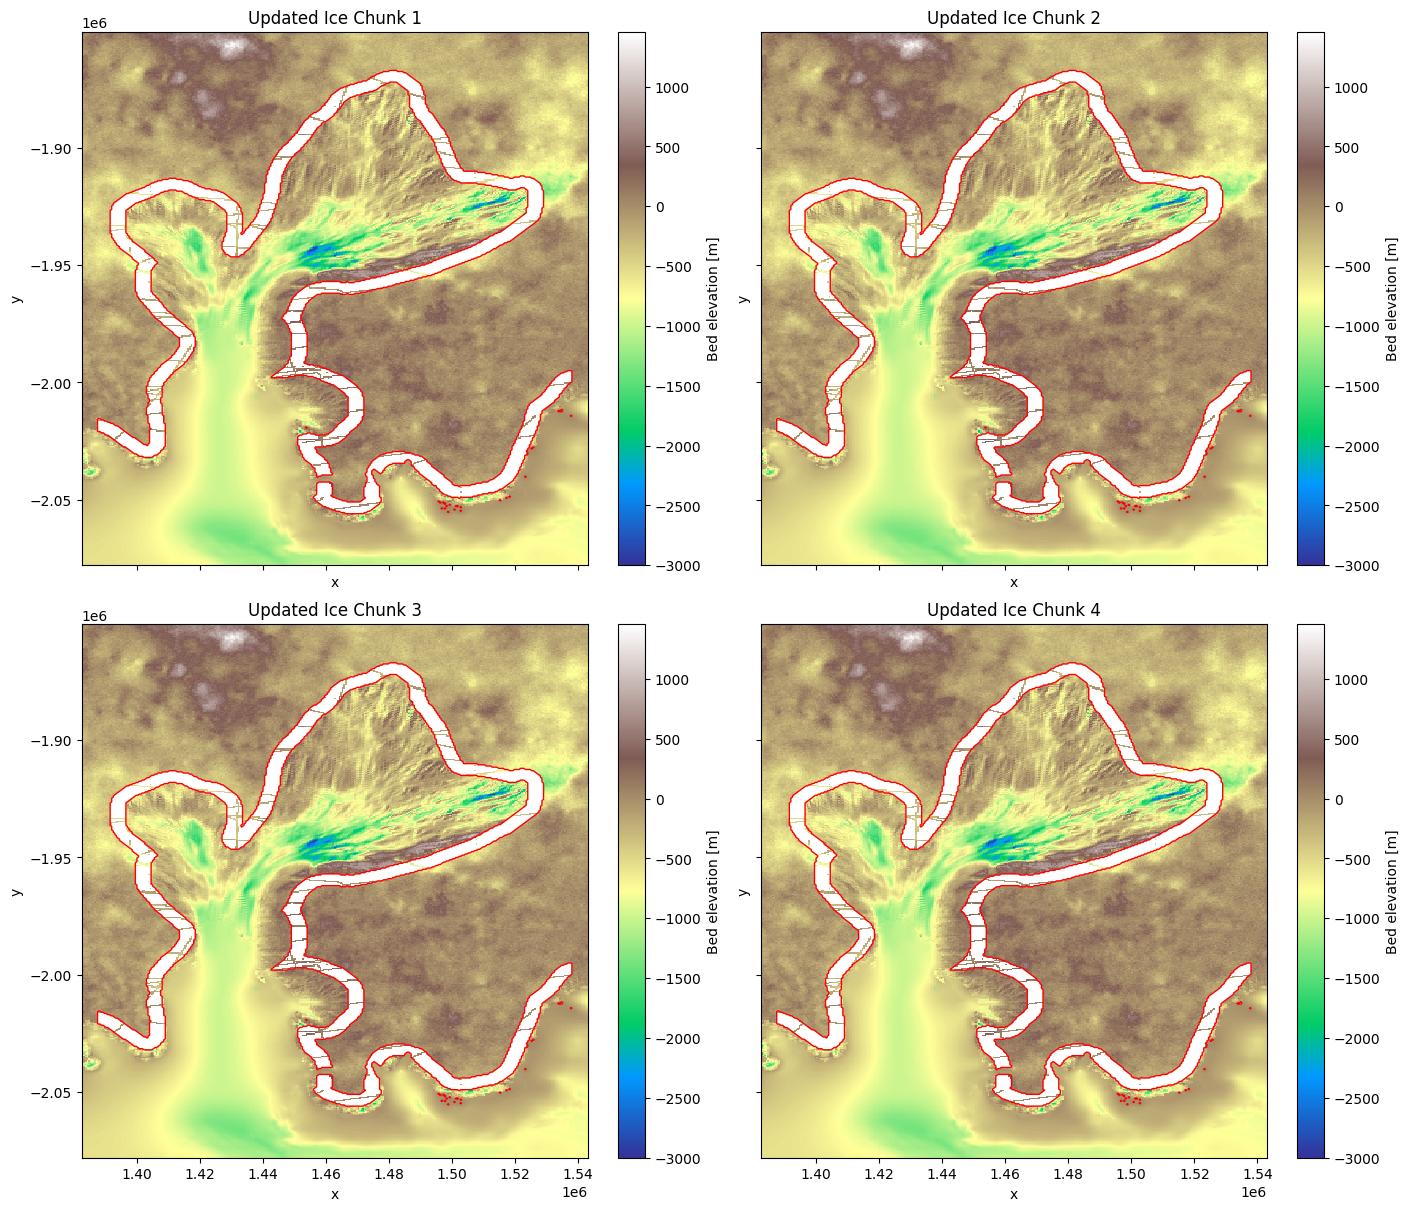

In [2]:
ice_chunk_updated = updata.build_ice_chunk_updated()

# plot four updated realizations from the stack
plot_indices = [0, 1, 2, 3]
shared_vmin = np.nanmin(ice_chunk_updated[plot_indices])
shared_vmax = np.nanmax(ice_chunk_updated[plot_indices])

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True, sharex=True, sharey=True)

for ax, idx in zip(axes.flat, plot_indices):
    im = ax.pcolormesh(
        updata.coord[0],
        updata.coord[1],
        ice_chunk_updated[idx],
        cmap='terrain',
        vmin=shared_vmin,
        vmax=shared_vmax,
    )
    ax.contour(updata.coord[0], updata.coord[1], updata.mask.astype(float), levels=[0.5], colors='red', linewidths=1.0)
    ax.set_title(f'Updated Ice Chunk {idx + 1}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    fig.colorbar(im, ax=ax, label='Bed elevation [m]')

plt.show()


In [3]:
ice_chunk_stack_final = updata.sgs_simulation()

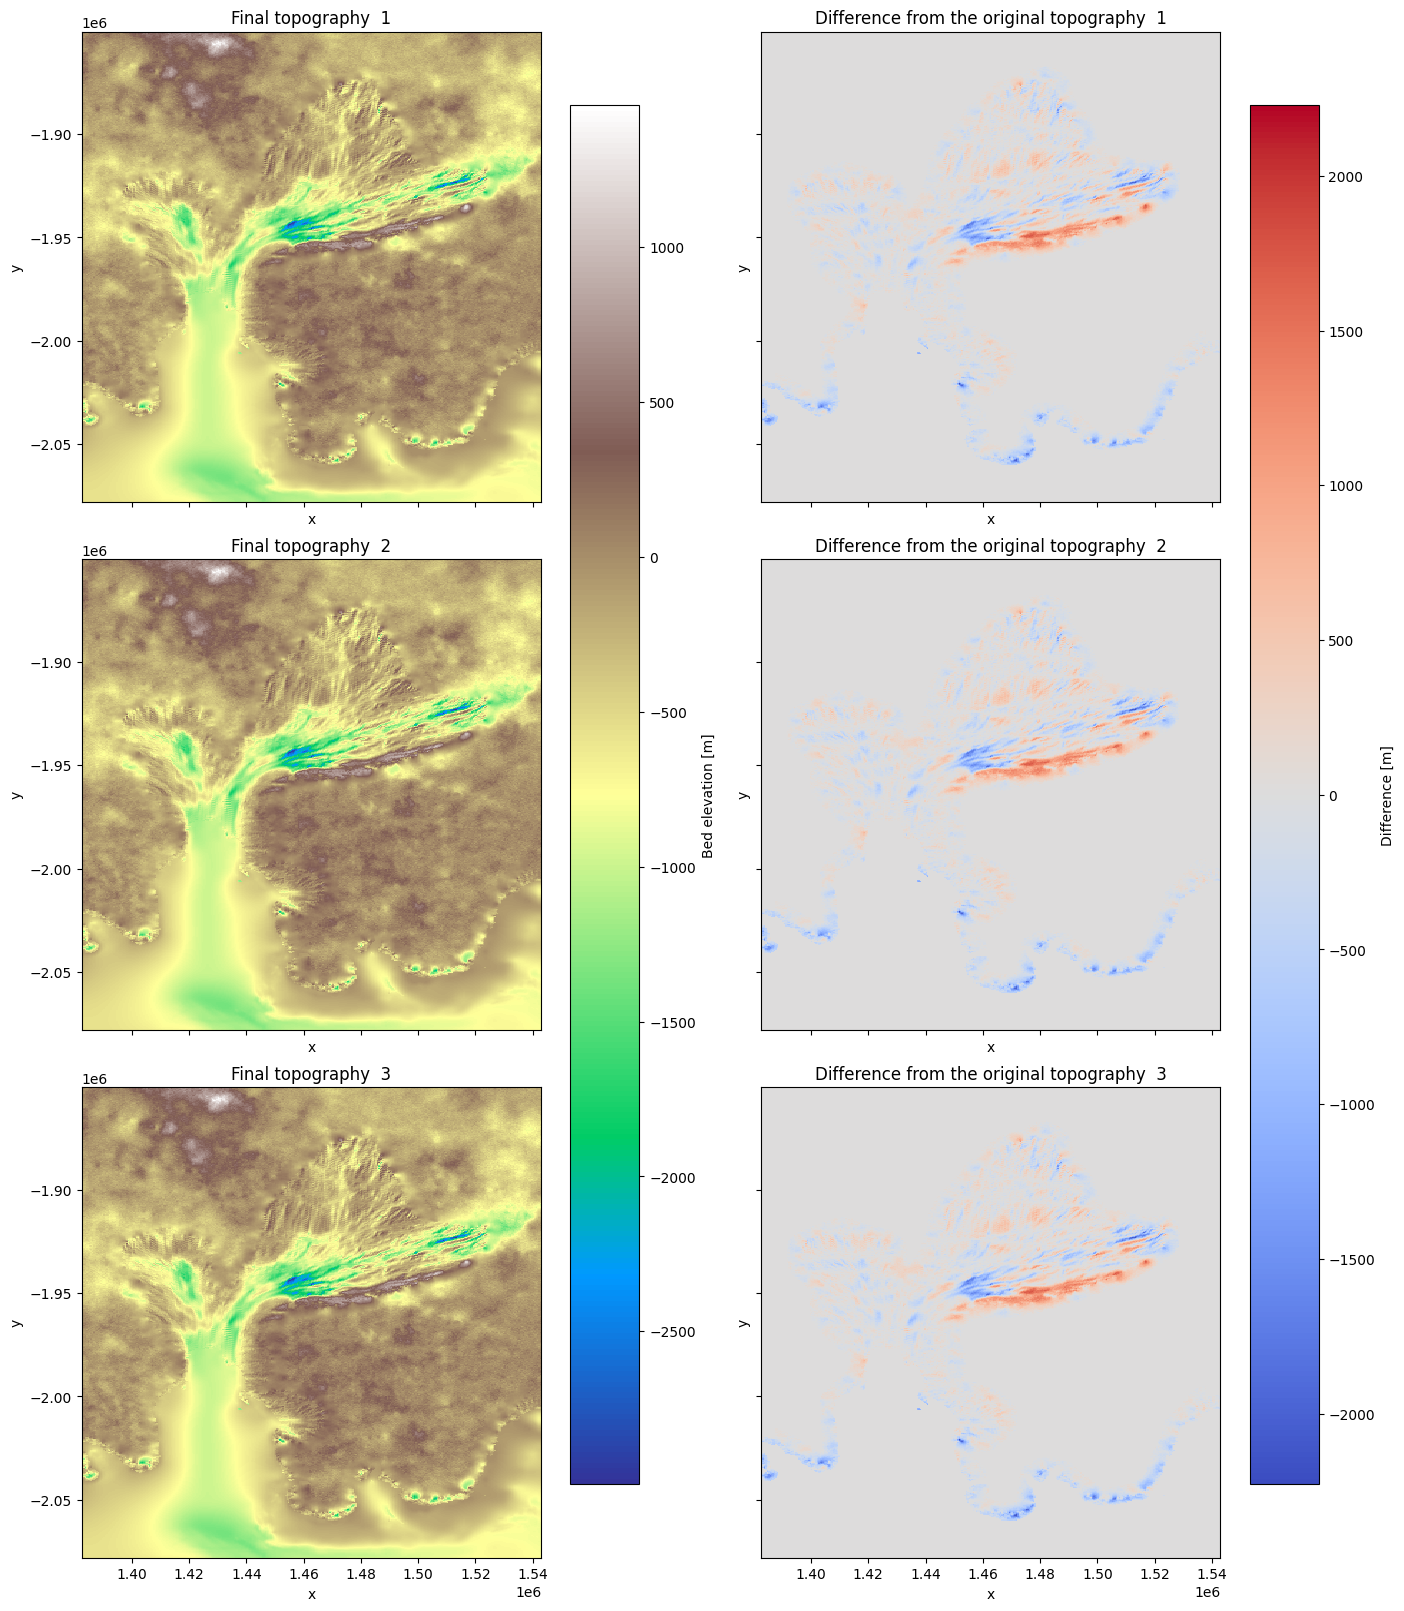

In [7]:
plot_indices = [0, 1, 2]
trimmed_stack = updata.ice_chunk_stack
final_stack = ice_chunk_stack_final
diff_stack = final_stack - trimmed_stack

shared_vmin = np.nanmin(final_stack[plot_indices])
shared_vmax = np.nanmax(final_stack[plot_indices])
diff_abs = np.nanmax(np.abs(diff_stack[plot_indices]))

fig, axes = plt.subplots(3, 2, figsize=(14, 16), constrained_layout=True, sharex=True, sharey=True)

for row, idx in enumerate(plot_indices):
    im0 = axes[row, 0].pcolormesh(
        updata.coord[0],
        updata.coord[1],
        final_stack[idx],
        cmap='terrain',
        vmin=shared_vmin,
        vmax=shared_vmax,
    )
    axes[row, 0].set_title(f'Final topography  {idx + 1}')
    axes[row, 0].set_xlabel('x')
    axes[row, 0].set_ylabel('y')

    im1 = axes[row, 1].pcolormesh(
        updata.coord[0],
        updata.coord[1],
        diff_stack[idx],
        cmap='coolwarm',
        vmin=-diff_abs,
        vmax=diff_abs,
    )
    axes[row, 1].set_title(f'Difference from the original topography  {idx + 1}')
    axes[row, 1].set_xlabel('x')
    axes[row, 1].set_ylabel('y')

fig.colorbar(im0, ax=axes[:, 0], label='Bed elevation [m]')
fig.colorbar(im1, ax=axes[:, 1], label='Difference [m]')
plt.show()

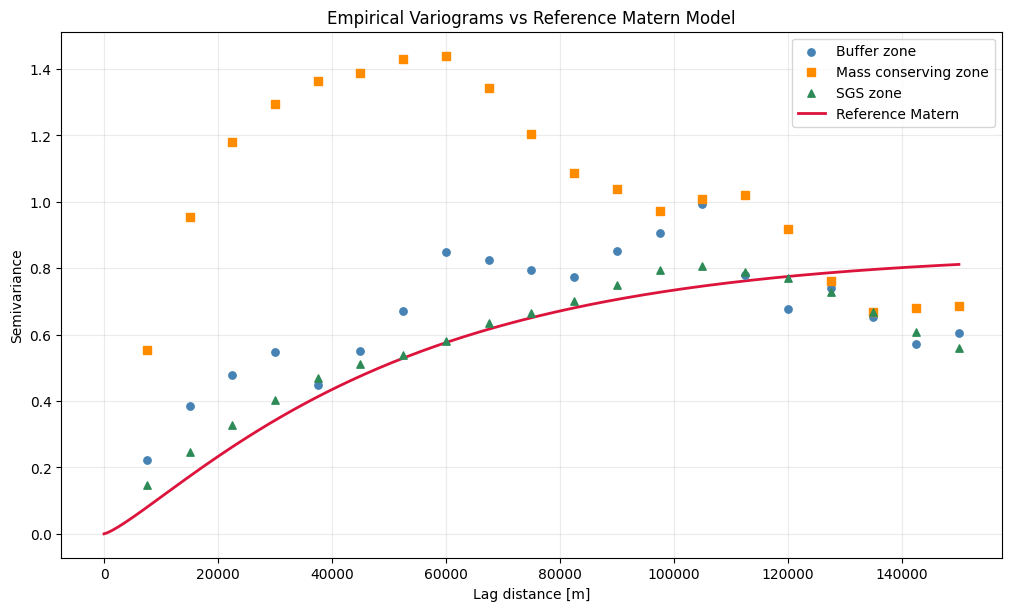

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import skgstat as skg
from skgstat import models
from sklearn.preprocessing import QuantileTransformer

df_masks = pd.read_csv(updata.coord_csv)
xx, yy = updata.coord
surface = ice_chunk_stack_final[0]
n_quantiles = min(500, len(xx))
nst_trans = QuantileTransformer(
    n_quantiles=n_quantiles,
    output_distribution='normal',
    random_state=0,
).fit(surface.reshape(-1, 1))
surface = nst_trans.transform(surface.reshape(-1, 1)).reshape(surface.shape)

inv_mask = df_masks['highvel_mask'].values.reshape(xx.shape) == 1
bedmap_mask = df_masks['bedmap_mask'].values.reshape(xx.shape) == 1
buffer_mask = updata.mask.astype(bool)
outside_mask = (~inv_mask) & (~buffer_mask) & (bedmap_mask == 1)

major_range = 140743
sill = 0.85
nugget = 0
smoothness = 0.66
maxlag = 150000
n_lags = 20
rng = np.random.default_rng(2002)
max_points = 4000

regions = {
    'Buffer zone': buffer_mask,
    'Mass conserving zone': inv_mask,
    'SGS zone': outside_mask,
}

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
lags_model = np.linspace(0, maxlag, 300)
gamma_model = models.matern(lags_model, major_range, sill, smoothness, b=nugget)

colors = ['steelblue', 'darkorange', 'seagreen']
markers = ['o', 's', '^']

for (title, region_mask), color, marker in zip(regions.items(), colors, markers):
    coords = np.column_stack((xx[region_mask], yy[region_mask]))
    values = surface[region_mask]

    if len(values) > max_points:
        keep = rng.choice(len(values), size=max_points, replace=False)
        coords = coords[keep]
        values = values[keep]

    V = skg.Variogram(
        coords,
        values,
        model='matern',
        n_lags=n_lags,
        maxlag=maxlag,
        use_nugget=True,
        normalize=False,
    )

    ax.scatter(V.bins, V.experimental, s=28, color=color, marker=marker,
               label=f'{title}', zorder=3)

ax.plot(lags_model, gamma_model, color='crimson', lw=2, label='Reference Matern')
ax.set_title('Empirical Variograms vs Reference Matern Model')
ax.set_xlabel('Lag distance [m]')
ax.set_ylabel('Semivariance')
ax.grid(alpha=0.25)
ax.legend()
plt.show()
